# Hybrid Fake News Detection using Attention and Transformer Models
### Option 3: Hybrid Project (Comparison-Based)


In [1]:
pip install pandas numpy scikit-learn matplotlib nltk sentence-transformers transformers datasets accelerate torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

from sentence_transformers import SentenceTransformer

c:\Users\Lenovo\Downloads\NLP PROJ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [5]:
# Preprocessing
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)

## Model 1: TF-IDF + SVM (Baseline)

TF-IDF + SVM Accuracy: 0.9953229398663697


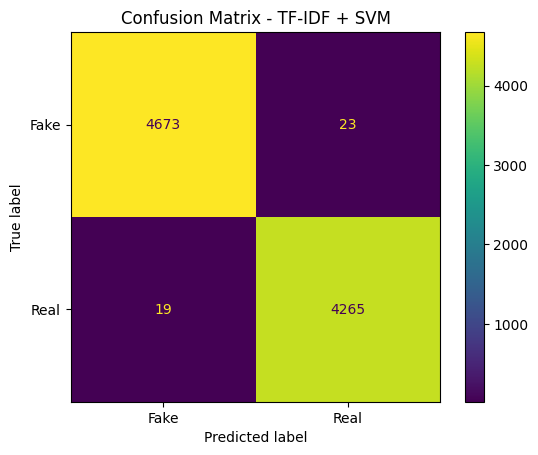

In [6]:
# TF-IDF + SVM
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))

X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

svm_tfidf = LinearSVC(random_state=42)
svm_tfidf.fit(X_train, y_train)

y_pred = svm_tfidf.predict(X_test)

tfidf_accuracy  = accuracy_score(y_test, y_pred)
tfidf_f1        = f1_score(y_test, y_pred)
tfidf_precision = precision_score(y_test, y_pred)
tfidf_recall    = recall_score(y_test, y_pred)

print("TF-IDF + SVM Accuracy:", tfidf_accuracy)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot()
plt.title("Confusion Matrix - TF-IDF + SVM")
plt.show()

## Model 2: BERT Embeddings + SVM

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1273.42it/s]


BERT + SVM Accuracy: 0.9719376391982183


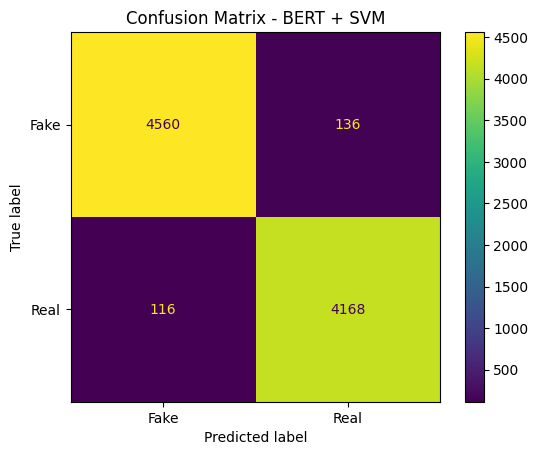

In [7]:
# BERT Embeddings + SVM
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

X_bert = bert_model.encode(df["text"].tolist(), batch_size=32)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bert, y, test_size=0.2, random_state=42, stratify=y
)

svm_bert = LinearSVC(random_state=42)
svm_bert.fit(Xb_train, yb_train)

yb_pred = svm_bert.predict(Xb_test)

bert_accuracy  = accuracy_score(yb_test, yb_pred)
bert_f1        = f1_score(yb_test, yb_pred)
bert_precision = precision_score(yb_test, yb_pred)
bert_recall    = recall_score(yb_test, yb_pred)

print("BERT + SVM Accuracy:", bert_accuracy)

cm = confusion_matrix(yb_test, yb_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot()
plt.title("Confusion Matrix - BERT + SVM")
plt.show()

## Model 3: DistilBERT Fine-Tuning (Pretrained Transformer)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 922.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\Lenovo\Downloads\NLP PROJ\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.004973,0.000440,0.999889,0.999883,0.999767,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]
c:\Users\Lenovo\Downloads\NLP PROJ\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Lenovo\Downloads\NLP PROJ\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.004973,0.000440,1,0.999889,0.999883,0.999767,1.000000


DistilBERT Accuracy: 0.9998886414253898


c:\Users\Lenovo\Downloads\NLP PROJ\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


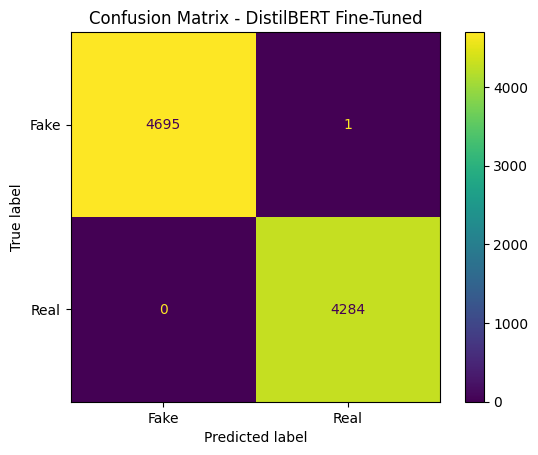

In [10]:
# DistilBERT Fine-Tuning
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

train_df = pd.DataFrame({"text": train_texts.tolist(), "label": train_labels.tolist()})
test_df  = pd.DataFrame({"text": test_texts.tolist(),  "label": test_labels.tolist()})

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)

train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
test_dataset  = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset  = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall":    recall_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    report_to="none"
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
eval_results = trainer.evaluate()

finetuned_accuracy  = eval_results["eval_accuracy"]
finetuned_f1        = eval_results["eval_f1"]
finetuned_precision = eval_results["eval_precision"]
finetuned_recall    = eval_results["eval_recall"]

print("DistilBERT Accuracy:", finetuned_accuracy)

# --- Confusion Matrix for DistilBERT ---
distilbert_preds = trainer.predict(test_dataset)
distilbert_pred_labels = np.argmax(distilbert_preds.predictions, axis=-1)
distilbert_true_labels = distilbert_preds.label_ids

cm = confusion_matrix(distilbert_true_labels, distilbert_pred_labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot()
plt.title("Confusion Matrix - DistilBERT Fine-Tuned")
plt.show()

## Model 4: Simplified Attention Model (Built from Scratch)

In [11]:
# Smaller TF-IDF for Attention model
tfidf_small = TfidfVectorizer(max_features=100)
X_small = tfidf_small.fit_transform(df["clean_text"])

# --- FIX: proper train/test split ---
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42, stratify=y
)

# Use a sample of TRAIN only for training (due to compute limits)
X_train_sample = Xs_train[:500].toarray()
y_train_sample = ys_train[:500].values

# Use the actual TEST set for evaluation
X_test_sample  = Xs_test[:200].toarray()
y_test_sample  = ys_test[:200].values

scaler = StandardScaler()
X_train_sample = scaler.fit_transform(X_train_sample)
X_test_sample  = scaler.transform(X_test_sample)   # use same scaler, no refit

In [12]:
# Self-Attention visualization (demonstration)
Q = torch.tensor(X_train_sample[:10], dtype=torch.float32)
K = Q.clone()
V = Q.clone()

scores = torch.matmul(Q, K.T) / (K.shape[-1] ** 0.5)
weights = F.softmax(scores, dim=-1)
attention_output = torch.matmul(weights, V)
print("Attention output shape:", attention_output.shape)

Attention output shape: torch.Size([10, 100])


In [16]:
# Attention Model Definition
class SimpleAttentionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.Wq = nn.Linear(input_dim, input_dim)
        self.Wk = nn.Linear(input_dim, input_dim)
        self.Wv = nn.Linear(input_dim, input_dim)
        self.fc  = nn.Linear(input_dim, 2)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
        weights = torch.softmax(scores, dim=-1)
        out     = torch.matmul(weights, V).mean(dim=1)
        return self.fc(out)

In [17]:
# Training
attention_model = SimpleAttentionModel(X_train_sample.shape[1])
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(attention_model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train_sample, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sample, dtype=torch.long)

for epoch in range(10):
    attention_model.train()
    optimizer.zero_grad()
    outputs = attention_model(X_train_tensor.unsqueeze(1))
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/10 — Loss: {loss.item():.4f}")

Epoch 2/10 — Loss: 0.6374
Epoch 4/10 — Loss: 0.5426
Epoch 6/10 — Loss: 0.4670
Epoch 8/10 — Loss: 0.4072
Epoch 10/10 — Loss: 0.3599


Attention Model Accuracy (on test set): 0.88
Attention Model F1 Score: 0.8823529411764706


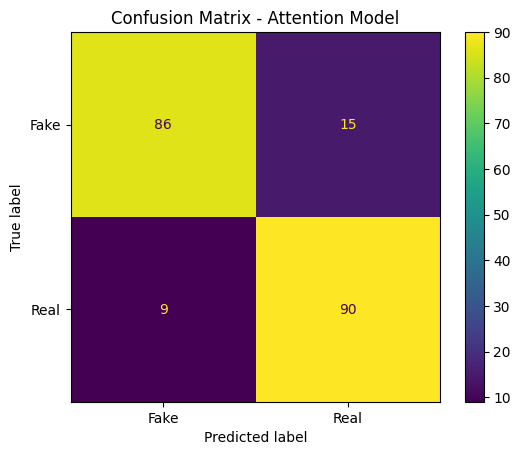

In [18]:
# --- FIX: Evaluate on TEST set, not training data ---
attention_model.eval()

X_test_tensor = torch.tensor(X_test_sample, dtype=torch.float32)

with torch.no_grad():
    outputs = attention_model(X_test_tensor.unsqueeze(1))
    preds   = torch.argmax(outputs, dim=1).numpy()

attention_accuracy  = accuracy_score(y_test_sample, preds)
attention_f1        = f1_score(y_test_sample, preds, zero_division=0)
attention_precision = precision_score(y_test_sample, preds, zero_division=0)
attention_recall    = recall_score(y_test_sample, preds, zero_division=0)

print("Attention Model Accuracy (on test set):", attention_accuracy)
print("Attention Model F1 Score:", attention_f1)

# --- FIX: Confusion Matrix for Attention ---
cm = confusion_matrix(y_test_sample, preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot()
plt.title("Confusion Matrix - Attention Model")
plt.show()

## Final Comparison

In [19]:
# --- FIX: Full metrics in comparison table ---
results = pd.DataFrame({
    "Model":     ["TF-IDF + SVM", "BERT + SVM", "DistilBERT (Fine-Tuned)", "Attention (Scratch)"],
    "Accuracy":  [tfidf_accuracy,  bert_accuracy,  finetuned_accuracy,  attention_accuracy],
    "F1 Score":  [tfidf_f1,        bert_f1,        finetuned_f1,        attention_f1],
    "Precision": [tfidf_precision, bert_precision, finetuned_precision, attention_precision],
    "Recall":    [tfidf_recall,    bert_recall,    finetuned_recall,    attention_recall]
})

print(results.to_string(index=False))

                  Model  Accuracy  F1 Score  Precision   Recall
           TF-IDF + SVM  0.995323  0.995100   0.994636 0.995565
             BERT + SVM  0.971938  0.970657   0.968401 0.972923
DistilBERT (Fine-Tuned)  0.999889  0.999883   0.999767 1.000000
    Attention (Scratch)  0.880000  0.882353   0.857143 0.909091


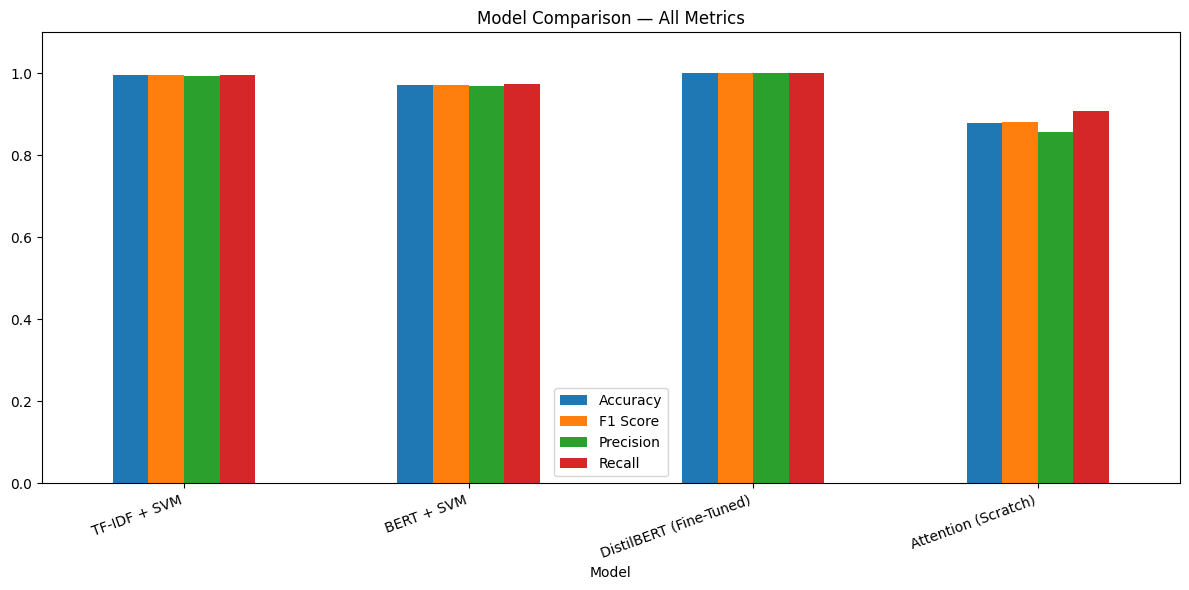

In [20]:
# Bar Chart — all 4 metrics
results.plot(
    x="Model",
    y=["Accuracy", "F1 Score", "Precision", "Recall"],
    kind="bar",
    figsize=(12, 6)
)
plt.title("Model Comparison — All Metrics")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()